
#  Analyse Client & Segmentation

##  Objectif
Ce notebook a pour objectif de transformer des données transactionnelles clients en informations exploitables pour la segmentation et la modélisation. Il combine ingénierie de features, visualisation, réduction de dimension, clustering (K-means, DBSCAN) et modélisation prédictive.

##  Plan
1. **Présentation** : Objectifs et plan
2. **Chargement des données & aperçu**
3. **Ingénierie de features**
4. **Visualisation**
5. **Détection des outliers**
6. **Réduction de dimension (ACP)**
7. **Segmentation par K-means**
8. **Modélisation prédictive**
9. **Segmentation par DBSCAN**
10. **Conclusion**


In [ ]:
import pandas as pd
file_path = "df_sans_features.csv"

df = pd.read_csv(file_path)

# Affiche les premières infos
df.head()

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,...,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,...,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,...,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,...,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,...,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,...,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison


In [ ]:
df.describe(include='all')

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,...,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
count,111705,111705,111705.000000,111705,111705,111705,111705,111705,111705,111705,...,111705.000000,111705.000000,111705,111705,111705.000000,111705.000000,111705.000000,111705,111705,111705
unique,97916,94720,NaN,4108,27,97916,7,97370,615,50469,...,NaN,NaN,32789,3090,NaN,NaN,NaN,611,23,20
top,fc3d1daec319d62d49bfb5e1f83123e9,c8460e4251689ba205045f3ea17884a1,NaN,sao paulo,São Paulo,8272b63d03f5f79c56e9e4120aec44ef,delivered,2017-07-16 18:19:25,2017-11-24,15:30:41,...,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN,sao paulo,SP,Maison
freq,21,24,NaN,17669,47125,21,109367,21,1352,23,...,NaN,NaN,524,2014,NaN,NaN,NaN,27745,79661,31691
mean,NaN,NaN,35129.466076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.033597,1.195273,NaN,NaN,120.556914,19.989187,24447.946896,NaN,NaN,NaN
std,NaN,NaN,29891.244030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.387014,0.689177,NaN,NaN,182.507246,15.804750,27605.113502,NaN,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,NaN,0.850000,0.000000,1001.000000,NaN,NaN,NaN
25%,NaN,NaN,11250.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,1.000000,NaN,NaN,39.900000,13.080000,6429.000000,NaN,NaN,NaN
50%,NaN,NaN,24320.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000,1.000000,NaN,NaN,74.990000,16.260000,13566.000000,NaN,NaN,NaN
75%,NaN,NaN,59062.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000,1.000000,NaN,NaN,134.900000,21.150000,28035.000000,NaN,NaN,NaN


In [ ]:
etat_to_cep = {
    'São Paulo': '01000',
    'Santa Catarina': '88000',
    'Minas Gerais': '30000',
    'Paraná': '80000',
    'Rio de Janeiro': '20000',
    'Rio Grande do Sul': '90000',
    'Pará': '66000',
    'Goiás': '74000',
    'Espírito Santo': '29000',
    'Bahia': '40000',
    'Maranhão': '65000',
    'Mato Grosso do Sul': '79000',
    'Ceará': '60000',
    'Distrito Federal': '70000',
    'Rio Grande do Norte': '59000',
    'Pernambuco': '50000',
    'Mato Grosso': '78000',
    'Amazonas': '69000',
    'Amapá': '68900',
    'Alagoas': '57000',
    'Rondônia': '76800',
    'Paraíba': '58000',
    'Tocantins': '77000',
    'Piauí': '64000',
    'Acre': '69900',
    'Sergipe': '49000',
    'Roraima': '69300'
}
df['état_client'].unique()
df['cp_etats_clients'] = df['état_client'].map(etat_to_cep)
df

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,...,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit,cp_etats_clients
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,...,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison,01000
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,...,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison,01000
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,...,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison,01000
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,...,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison,01000
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,...,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison,01000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111700,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,...,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,Multimédias,01000
111701,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,...,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,Sport & Loisirs,01000
111702,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,...,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,Beauté & Santé,60000
111703,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,...,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,Cadeaux & Montres,90000


# Propositions de features centrées sur le client

📦 Comportement d’achat
Feature	Description
nombre_commandes	Nombre total de commandes passées
montant_total_acheté	Somme totale dépensée (produit + livraison)
panier_moyen	Montant moyen par commande
variete_categories	Nombre de catégories de produits différentes achetées
recence	Nombre de jours depuis la dernière commande
frequence_commande_mensuelle	Nombre moyen de commandes par mois
jours_entre_commandes_moyen	Délai moyen entre les commandes

🌟 Satisfaction
Feature	Description
note_moyenne	Note moyenne laissée sur les produits
taux_avis	Proportion de commandes ayant donné lieu à un avis
note_max, note_min, écart_type_notes	Analyse de la cohérence de la satisfaction

💳 Paiement
Feature	Description
types_paiement_utilisés	Nombre de types de paiements différents utilisés
paiement_en_plusieurs_fois	Taux de paiements en plusieurs fois
moyenne_nbre_paiements	Moyenne du nombre d’échéances

🌍 Localisation
Feature	Description
état_client	Variable catégorielle à encoder (pour clustering géographique)
code_postal_client	Peut être regroupé ou codé comme densité régionale (si info dispo)



In [ ]:
# Sélection des colonnes pertinentes
df['date_commande'] = pd.to_datetime(df['date_commande'])
df = df.to_csv('df_all.csv')
df

In [ ]:
# Création des FEATURES

# Création d'un dataframe agrégé par client
df_clients = df.groupby('identifiant_unique_client').agg(
    nombre_commandes=('identifiant_commande', 'nunique'),
    montant_total_acheté=('montant_paiement', 'sum'),
    panier_moyen=('montant_paiement', 'mean'),
    note_moyenne=('note_avis', 'mean'),
    taux_avis=('note_avis', lambda x: x.notna().mean()),
    types_paiement_utilisés=('type_paiement', 'nunique'),
    paiement_en_plusieurs_fois=('nombre_paiements', lambda x: (x > 1).mean()),
    moyenne_nbre_paiements=('nombre_paiements', 'mean'),
    variete_categories=('categorie_produit', 'nunique'),
    dernier_achat=('date_commande', 'max'),
    premier_achat=('date_commande', 'min'),
    etat_client=('état_client', 'first'),
    code_postal_client=('code_postal_client', 'first'),
    cp_etats_clients=('cp_etats_clients','first')
).reset_index()

# Calcul de la récence et fréquence d'achat
df_clients['recence'] = (df['date_commande'].max() - df_clients['dernier_achat']).dt.days
df_clients['anciennete'] = (df_clients['dernier_achat'] - df_clients['premier_achat']).dt.days + 1
df_clients['frequence_commande_mensuelle'] = df_clients['nombre_commandes'] / (df_clients['anciennete'] / 30.0)
df_clients['jours_entre_commandes_moyen'] = df_clients['anciennete'] / df_clients['nombre_commandes']
df_clients.to_csv('df_clients.csv')
df_clients.head()


AttributeError: 'NoneType' object has no attribute 'groupby'

# 1. Analyse des corrélations entre variables

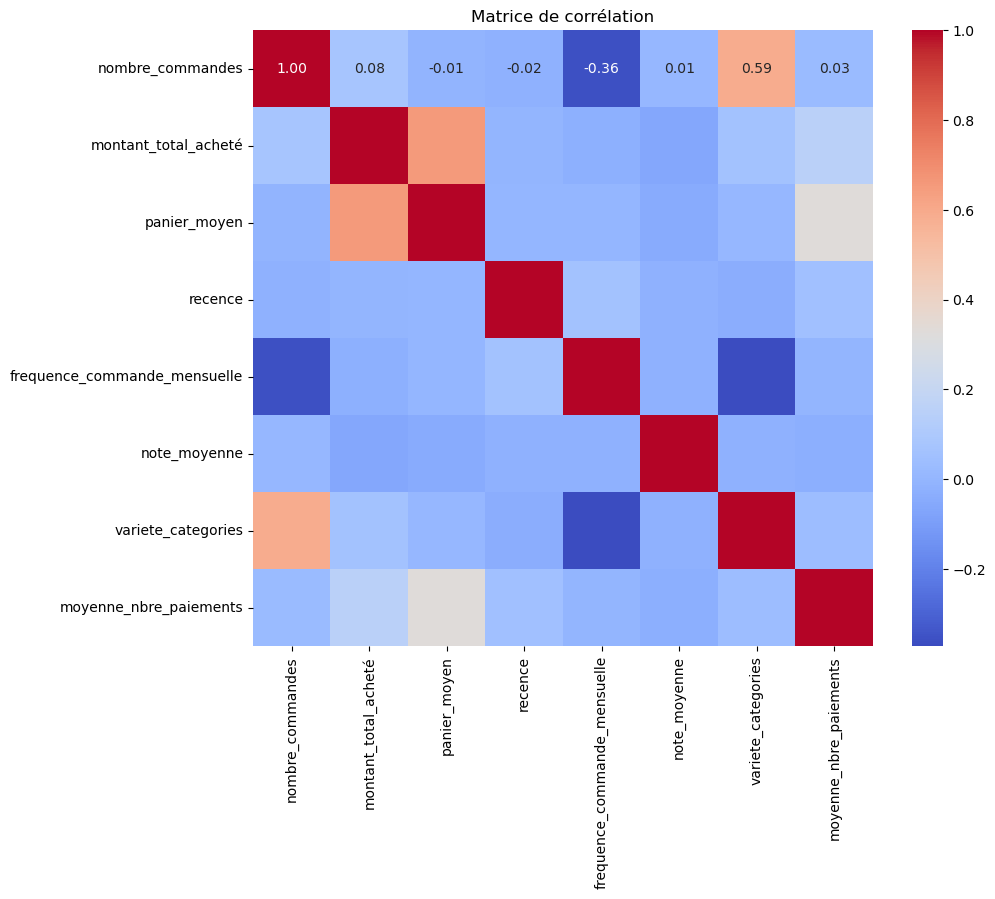

In [ ]:
# Import des librairies +
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = [
    'nombre_commandes', 'montant_total_acheté', 'panier_moyen',
    'recence', 'frequence_commande_mensuelle', 'note_moyenne',
    'variete_categories', 'moyenne_nbre_paiements'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_clients[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()


# 2. Détection d’outliers et normalisation

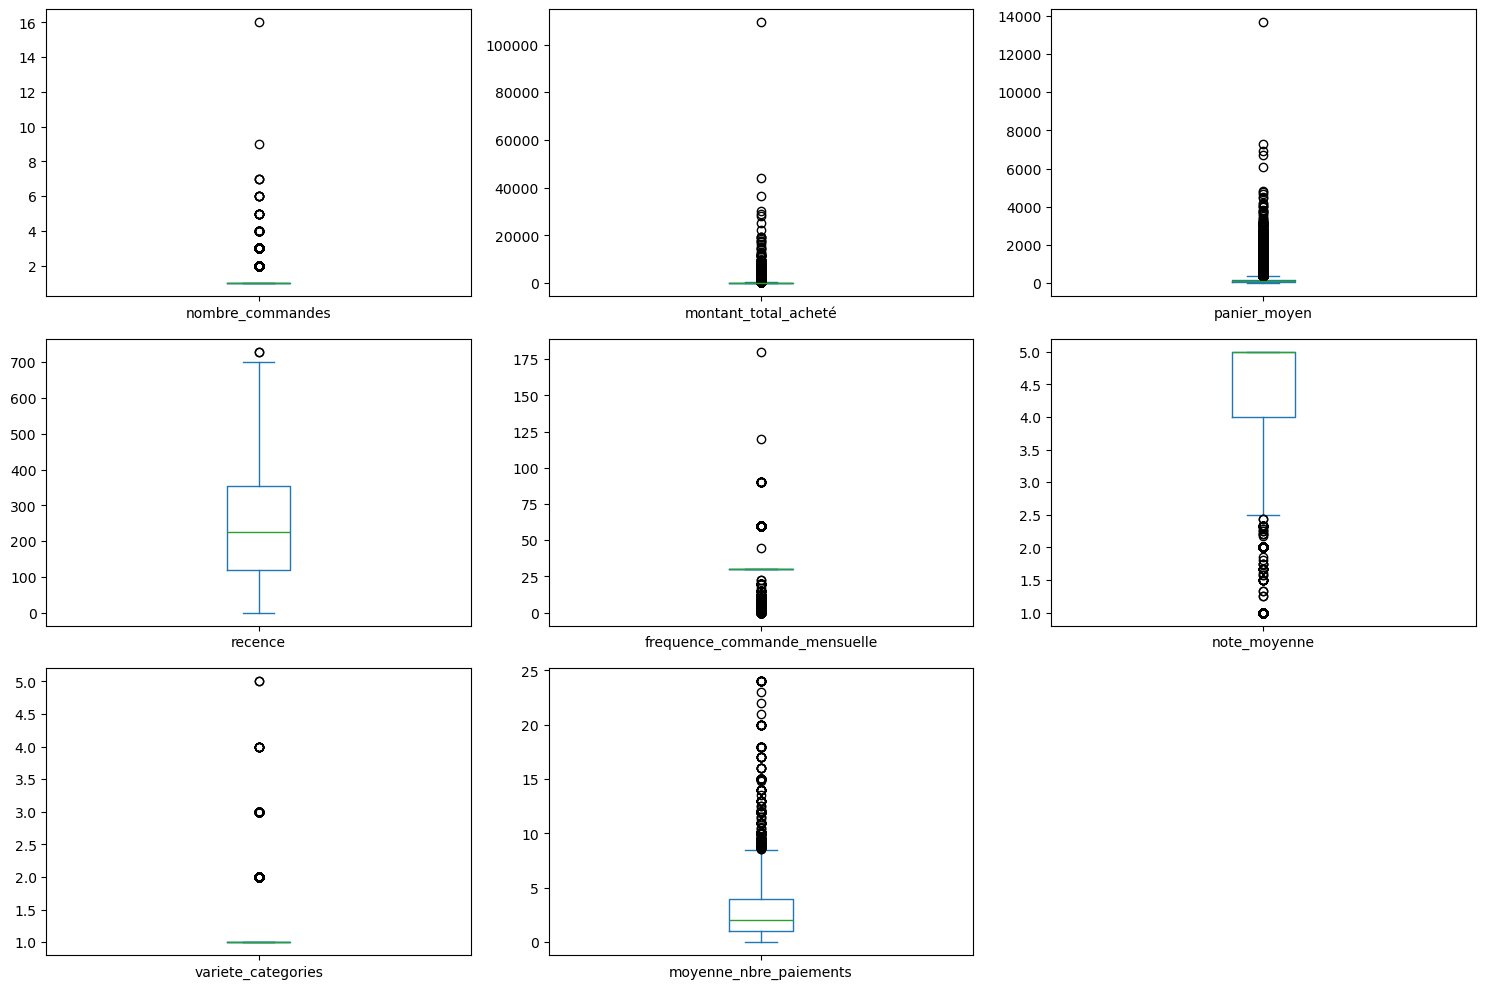

In [ ]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Boîte à moustaches pour visualiser les outliers
df_clients[numerical_features].plot(kind='box', subplots=True, figsize=(15, 10), layout=(3, 3), sharex=False)
plt.tight_layout()
plt.show()


Ce que fait le code suivants:
- Identifie les outliers pour chaque variable numérique
- Crée une colonne is_outlier (True/False) dans le DataFrame principal.
- Compteur du nombre d’outliers par variable.
- Affiche les identifiants (identifiant_unique_client) des clients outliers.

In [ ]:
# Initialisation
df_clients["is_outlier"] = False
outlier_counts = {}

# Détection des outliers
for col in numerical_features:
    Q1 = df_clients[col].quantile(0.25)
    Q3 = df_clients[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtrer les outliers
    outliers = df_clients[(df_clients[col] < lower_bound) | (df_clients[col] > upper_bound)]

    # Marquer les outliers dans la colonne "is_outlier"
    df_clients.loc[outliers.index, "is_outlier"] = True

    # Stocker le nombre d'outliers
    outlier_counts[col] = outliers.shape[0]

    # Afficher les identifiants des clients outliers
    print(f"Outliers pour '{col}' : {outliers.shape[0]} clients")
    print(outliers[["identifiant_unique_client", col]])
    print("-" * 50)

# Résumé : Nombre d'outliers par variable
print("Résumé - Nombre d'outliers par variable :")
for var, count in outlier_counts.items():
    print(f"{var} : {count} outliers")

# Nombre total de clients marqués comme outliers (au moins une variable)
print("\nNombre total de clients contenant au moins un outlier :", df_clients["is_outlier"].sum())


Outliers pour 'nombre_commandes' : 2869 clients
              identifiant_unique_client  nombre_commandes
105    004288347e5e88a27ded2bb23747066c                 2
122    004b45ec5c64187465168251cd1c9c2f                 2
142    0058f300f57d7b93c477a131a59b36c3                 2
245    00a39521eb40f7012db50455bf083460                 2
307    00cc12a6d8b578b8ebd21ea4e2ae8b27                 2
...                                 ...               ...
94388  ff22e30958c13ffe219db7d711e8f564                 2
94440  ff44401d0d8f5b9c54a47374eb48c1b8                 2
94546  ff8892f7c26aa0446da53d01b18df463                 2
94563  ff922bdd6bafcdf99cb90d7f39cea5b3                 3
94675  ffe254cc039740e17dd15a5305035928                 2

[2869 rows x 2 columns]
--------------------------------------------------
Outliers pour 'montant_total_acheté' : 9289 clients
              identifiant_unique_client  montant_total_acheté
7      00053a61a98854899e70ed204dd4bafe                838.36
18  

# 3. test avec le feature variete_categories

In [ ]:
# Séparer les features (X) de la cible (y)
# X = df_clients.drop('identifiant_unique_client', axis=1) # Original code
y = df_clients['variete_categories']

# Sélectionner uniquement les colonnes numériques pour X
# Utilise la liste numerical_features déjà définie
numerical_features = [
    'nombre_commandes', 'montant_total_acheté', 'panier_moyen',
    'recence', 'frequence_commande_mensuelle', 'note_moyenne',
    'variete_categories', 'moyenne_nbre_paiements',
    'taux_avis', 'types_paiement_utilisés', 'paiement_en_plusieurs_fois', 'moyenne_nbre_paiements', # Add other numerical features from df_clients
    'anciennete', 'frequence_commande_mensuelle', 'jours_entre_commandes_moyen' # Add calculated numerical features
]
# Ensure all numerical columns calculated earlier are included
numerical_features_all = [
    'nombre_commandes', 'montant_total_acheté', 'panier_moyen',
    'note_moyenne', 'taux_avis', 'types_paiement_utilisés',
    'paiement_en_plusieurs_fois', 'moyenne_nbre_paiements',
    'variete_categories', 'recence', 'anciennete',
    'frequence_commande_mensuelle', 'jours_entre_commandes_moyen'
]

X = df_clients[numerical_features_all].copy() # Select only numerical columns

# Sauvegarder les noms des colonnes pour plus tard
feature_names = X.columns

# Mettre les données à l'échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# X_scaled est maintenant un array NumPy, on peut le remettre en DataFrame pour l'afficher
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
print("\nAperçu des données mises à l'échelle (centrées-réduites) :")
print(X_scaled_df.head())


Aperçu des données mises à l'échelle (centrées-réduites) :
   nombre_commandes  montant_total_acheté  panier_moyen  note_moyenne  \
0         -0.160272             -0.107219     -0.075501      0.676486   
1         -0.160272             -0.291096     -0.602506     -0.077035   
2         -0.160272             -0.196473     -0.331308     -0.830555   
3         -0.160272             -0.264759     -0.527023     -0.077035   
4         -0.160272             -0.019072      0.177137      0.676486   

   taux_avis  types_paiement_utilisés  paiement_en_plusieurs_fois  \
0        0.0                -0.062715                    0.982904   
1        0.0                -0.062715                   -1.023096   
2        0.0                -0.062715                    0.982904   
3        0.0                -0.062715                    0.982904   
4        0.0                -0.062715                    0.982904   

   moyenne_nbre_paiements  variete_categories   recence  anciennete  \
0              

Étape 2 : L'ACP - Qu'est-ce que c'est et pourquoi l'utiliser ?
Utilité de l'ACP
L'ACP est une technique de réduction de dimension. Face à un grand nombre de variables, elle permet de :

Visualiser des données de haute dimension en les projetant sur 2 ou 3 dimensions, nous permettant de "voir" la structure des données, les clusters, les anomalies, etc.
Compresser les données en gardant le maximum d'information. Cela accélère les algorithmes et réduit les besoins en mémoire.
Lutter contre la multicolinéarité et le surapprentissage (overfitting). En combinant des variables corrélées en une seule composante, on réduit la redondance. En éliminant les dernières composantes (qui représentent souvent du bruit), on peut créer un modèle plus simple et plus robuste.
Principe de l'ACP
L'ACP ne sélectionne pas simplement un sous-ensemble de vos colonnes initiales. Au lieu de cela, elle crée de nouvelles variables, appelées Composantes Principales (CP).

Pensez à un nuage de points en 3D qui a la forme d'un cigare.

La première composante principale (CP1) sera l'axe qui traverse le cigare dans sa plus grande longueur. C'est la direction qui capture le plus de dispersion (variance) des données.
La deuxième composante (CP2) sera l'axe perpendiculaire au premier qui capture la deuxième plus grande dispersion (la largeur du cigare).
La troisième (CP3) sera perpendiculaire aux deux premières.
Ces nouvelles variables sont des combinaisons linéaires des anciennes, sont orthogonales (non corrélées) entre elles, et sont ordonnées par importance (quantité de variance expliquée).

# 4.  Application de l'ACP sur nos Données

In [ ]:
# Application de l'ACP sur nos Données
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

# Appliquer l'ACP sur les données mises à l'échelle
X_pca = pca.fit_transform(X_scaled)


# 5. Variance expliquée par chaque composante

Composante Principale 1: 0.2941 (29.41 % de la variance)
Composante Principale 2: 0.1714 (17.14 % de la variance)
Composante Principale 3: 0.1107 (11.07 % de la variance)
Composante Principale 4: 0.0845 (8.45 % de la variance)
Composante Principale 5: 0.0812 (8.12 % de la variance)
Composante Principale 6: 0.0683 (6.83 % de la variance)
Composante Principale 7: 0.0647 (6.47 % de la variance)
Composante Principale 8: 0.0407 (4.07 % de la variance)
Composante Principale 9: 0.0318 (3.18 % de la variance)
Composante Principale 10: 0.0288 (2.88 % de la variance)
Composante Principale 11: 0.0227 (2.27 % de la variance)
Composante Principale 12: 0.0010 (0.10 % de la variance)
Composante Principale 13: 0.0000 (0.00 % de la variance)


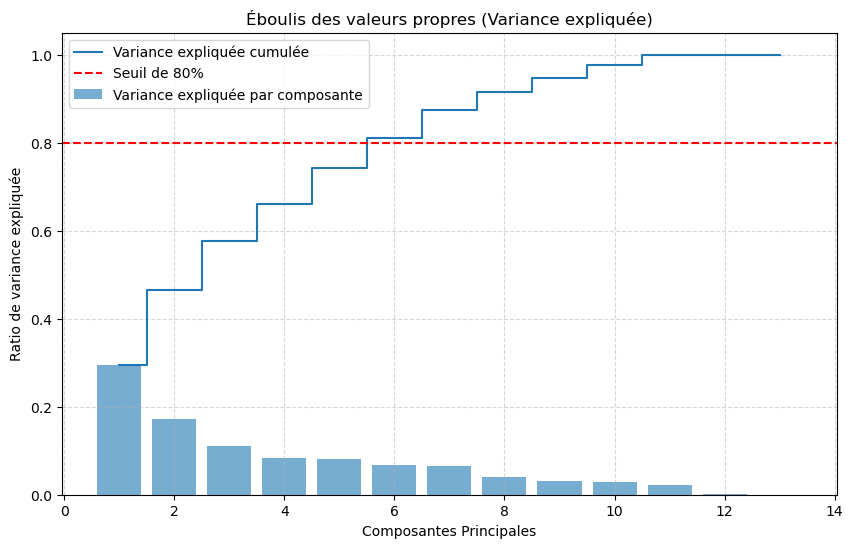

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_

for i, ratio in enumerate(explained_variance_ratio):
    print(f"Composante Principale {i+1}: {ratio:.4f} ({ratio*100:.2f} % de la variance)")

# Graphique de la variance expliquée cumulée (Éboulis des valeurs propres ou Scree Plot)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, align='center', label='Variance expliquée par composante')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Variance expliquée cumulée')
plt.ylabel('Ratio de variance expliquée')
plt.xlabel('Composantes Principales')
plt.title("Éboulis des valeurs propres (Variance expliquée)")
plt.axhline(y=0.8, color='r', linestyle='--', label='Seuil de 80%')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interprétation :

La CP1 explique à elle seule environ 29% de la variabilité totale de nos données.
La CP2 en explique environ 17%.
À elles deux, elles capturent 48% de l'information totale. On peut donc déjà visualiser  la moitié de l'information de notre dataset 5D sur un simple graphique 2D.
Le graphique, appelé "éboulis des valeurs propres", est crucial. Il nous montre le rendement décroissant de chaque nouvelle composante. On cherche souvent un "coude" dans ce graphique, un point où l'ajout d'une nouvelle composante n'apporte plus beaucoup de variance expliquée. Ici, on voit que les 4 premières composantes capturent environ 88% de la variance, ce qui est excellent.

In [ ]:
#  Les Composantes Principales
# Comment sont construites ces nouvelles composantes ? Le pca.components_ nous donne les "poids" de
# chaque variable d'origine dans la construction de chaque nouvelle composante.

components_df = pd.DataFrame(pca.components_, columns=feature_names, index=[f'CP{i+1}' for i in range(len(feature_names))])
print("Composition des Composantes Principales :")
print(components_df)

Composition des Composantes Principales :
      nombre_commandes  montant_total_acheté  panier_moyen  note_moyenne  \
CP1       4.013583e-01          4.594725e-02  1.225927e-02  5.329028e-03   
CP2      -5.862261e-04          4.349557e-01  5.232156e-01 -7.922943e-02   
CP3       5.183304e-03          5.748045e-01  4.396037e-01 -8.238984e-02   
CP4       8.646824e-02         -1.390996e-02 -6.084010e-02 -6.855891e-01   
CP5       5.168026e-02          8.071371e-02  7.631146e-02  7.126443e-01   
CP6       8.526492e-02         -2.758832e-02 -1.103025e-02  7.922460e-03   
CP7       5.120174e-01          2.328847e-02 -6.373639e-02  8.661000e-02   
CP8       2.049787e-01          2.700807e-02 -1.420423e-02 -1.798008e-02   
CP9       6.322847e-01          2.557605e-01 -2.593009e-01 -1.771976e-02   
CP10     -3.280638e-01          5.403100e-01 -4.961931e-01  2.669704e-02   
CP11     -7.060012e-02          3.349811e-01 -4.533070e-01  9.888578e-03   
CP12     -6.995913e-02          7.102718e-04 -

## Interprétation Détaillée :

Ces poids nous permettent de donner un sens métier à nos axes abstraits.

Chaque ligne (CP1 à CP13) est une composante principale, une direction dans l’espace des données, qui résume une partie de la variance totale.
Chaque colonne est une variable d’origine (ex: nombre_commandes, panier_moyen, recence, etc.).
Les coefficients (loadings) indiquent l’importance et le sens (positif ou négatif) de chaque variable sur l’axe.

✅ CP1 – Axe "Client Fidèle & Récent"
Variables avec forts coefficients :

nombre_commandes: 0.401

frequence_commande_mensuelle: -0.383

anciennete: 0.492

variete_categories: 0.377

jours_entre_commandes_moyen: 0.481

➡️ Interprétation :
Cet axe distingue les clients anciens et réguliers (valeurs positives) des clients récents et irréguliers (valeurs négatives).
Un score élevé reflète un client ancien, ayant commandé souvent (beaucoup de commandes, faible fréquence mensuelle) avec une diversité d’achats, mais espacés dans le temps.

✅ CP2 – Axe "Paiement Fractionné & Panier Moyen Élevé"
paiement_en_plusieurs_fois: 0.480

panier_moyen: 0.523

montant_total_acheté: 0.434

moyenne_nbre_paiements: 0.542

➡️ Interprétation :
Cet axe capture les clients à fort pouvoir d’achat, qui ont un panier moyen élevé, payent en plusieurs fois, et dépensent un montant total important.
Cela peut représenter des clients haut de gamme, ou stratégiques pour la valeur générée.

✅ CP3 – Axe "Gros Achat en Une Fois"
montant_total_acheté: 0.574

panier_moyen: 0.439

paiement_en_plusieurs_fois: -0.525

moyenne_nbre_paiements: -0.422

➡️ Interprétation :
Contrairement à CP2, ici on observe des clients ayant fait un gros achat unique ou peu fractionné, sans utiliser le paiement en plusieurs fois.
Il s'agit peut-être de clients occasionnels ayant passé un gros panier en une seule fois.

✅ CP4 – Axe "Clients Récents avec Note Basse"
note_moyenne: -0.685

recence: 0.704 (indique un achat récent)

variete_categories: 0.090

➡️ Interprétation :
Cet axe oppose des clients récents mais insatisfaits (note basse) à des clients plus anciens avec des évaluations plus hautes.
Cela peut signaler un problème dans la qualité récente du service/produit.

✅ CP5 – Axe "Satisfaction Client & Évaluation"
note_moyenne: 0.712

recence: 0.683

➡️ Interprétation :
Un axe où les clients récents donnent de bonnes notes, peut-être liés à une amélioration récente de l’offre/service.

✅ CP6 – Axe "Moyen de Paiement Dominant"
types_paiement_utilisés: 0.924

➡️ Interprétation :
Cette composante est dominée par les types de paiement utilisés.
Un score élevé indique des clients utilisant un moyen de paiement particulier (ex: carte, virement, etc.), ce qui pourrait être utile pour adapter les offres de fidélisation ou de facilités de paiement.

✅ CP7 – Axe "Fréquence d’Achat Active"
nombre_commandes: 0.512

frequence_commande_mensuelle: 0.511

➡️ Interprétation :
Cet axe met en évidence les clients très actifs, avec un nombre élevé de commandes et une fréquence mensuelle élevée.

✅ CP8 – Axe "Client Occasionnel Très Actif sur le Court Terme"
frequence_commande_mensuelle: 0.668

anciennete: 0.354

variete_categories: -0.504

➡️ Interprétation :
Client récent, très actif sur une période courte, mais avec une faible diversité.
➡️ Peut correspondre à des périodes de soldes ou d’achat ciblé.

✅ CP9 – Axe "Gros Client Fidèle"
nombre_commandes: 0.632

montant_total_acheté: 0.255

variete_categories: -0.458

➡️ Interprétation :
Ce sont probablement des gros clients réguliers, mais avec un comportement d'achat moins diversifié (catégories limitées).



# 6. Le Cercle des Corrélations

Cercle des corrélations pour les composantes 1 et 2


C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
posx and posy should be finite values
posx and posy should be finite values


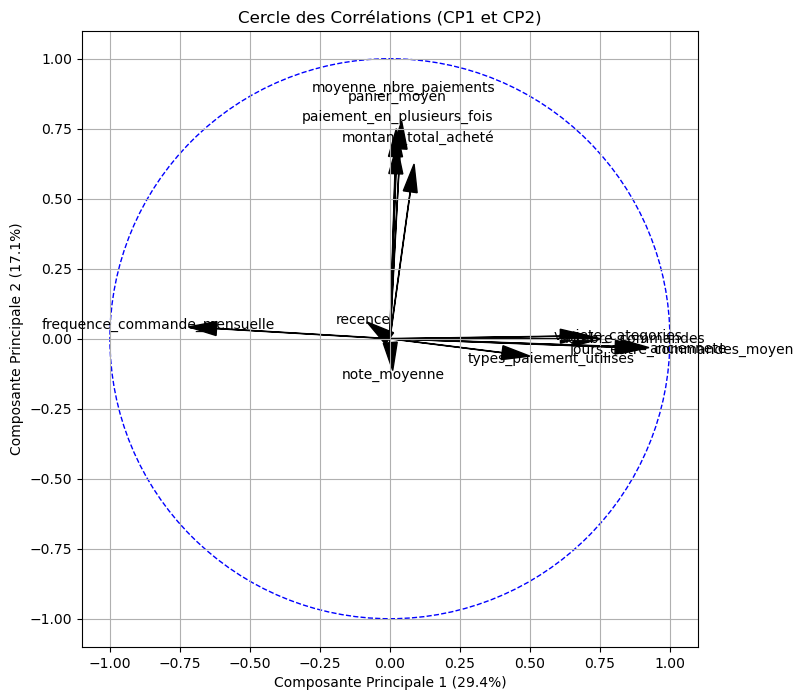

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Cercle des corrélations pour les composantes 3 et 4


posx and posy should be finite values
posx and posy should be finite values


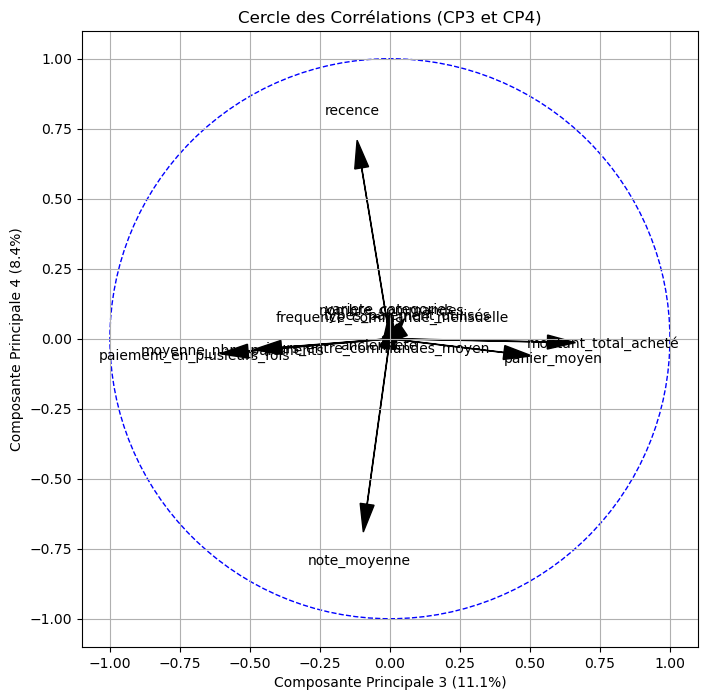

In [ ]:


def plot_correlation_circle(pca, X_scaled, feature_names, comp_x, comp_y, explained_variance_ratio):
    """Affiche le cercle des corrélations pour 2 composantes choisies."""

    # Corrélations entre les variables originales et les composantes principales
    X_pca = pca.transform(X_scaled)
    correlations = np.array([np.corrcoef(X_scaled[:, i], X_pca[:, j])[0, 1] for i in range(len(feature_names)) for j in range(len(feature_names))]).reshape(len(feature_names), -1)

    fig, ax = plt.subplots(figsize=(8, 8))

    for i, feature in enumerate(feature_names):
        ax.arrow(0, 0, correlations[i, comp_x-1], correlations[i, comp_y-1],
                 head_width=0.05, head_length=0.1, fc='k', ec='k', length_includes_head=True)
        ax.text(correlations[i, comp_x-1] * 1.15, correlations[i, comp_y-1] * 1.15,
                feature, color='k', ha='center', va='center')

    circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
    ax.add_artist(circle)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(f'Composante Principale {comp_x} ({explained_variance_ratio[comp_x-1]*100:.1f}%)')
    ax.set_ylabel(f'Composante Principale {comp_y} ({explained_variance_ratio[comp_y-1]*100:.1f}%)')
    ax.set_title(f'Cercle des Corrélations (CP{comp_x} et CP{comp_y})')
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')
    plt.show()

# Cercle pour les axes 1 et 2
print("Cercle des corrélations pour les composantes 1 et 2")
plot_correlation_circle(pca, X_scaled, feature_names, 1, 2, explained_variance_ratio)

# Cercle pour les axes 3 et 4
print("\nCercle des corrélations pour les composantes 3 et 4")
plot_correlation_circle(pca, X_scaled, feature_names, 3, 4, explained_variance_ratio)

Interprétation des cercles :

Plan 1-2 : On visualise très bien notre interprétation précédente ,

Plan 3-4 : La variable

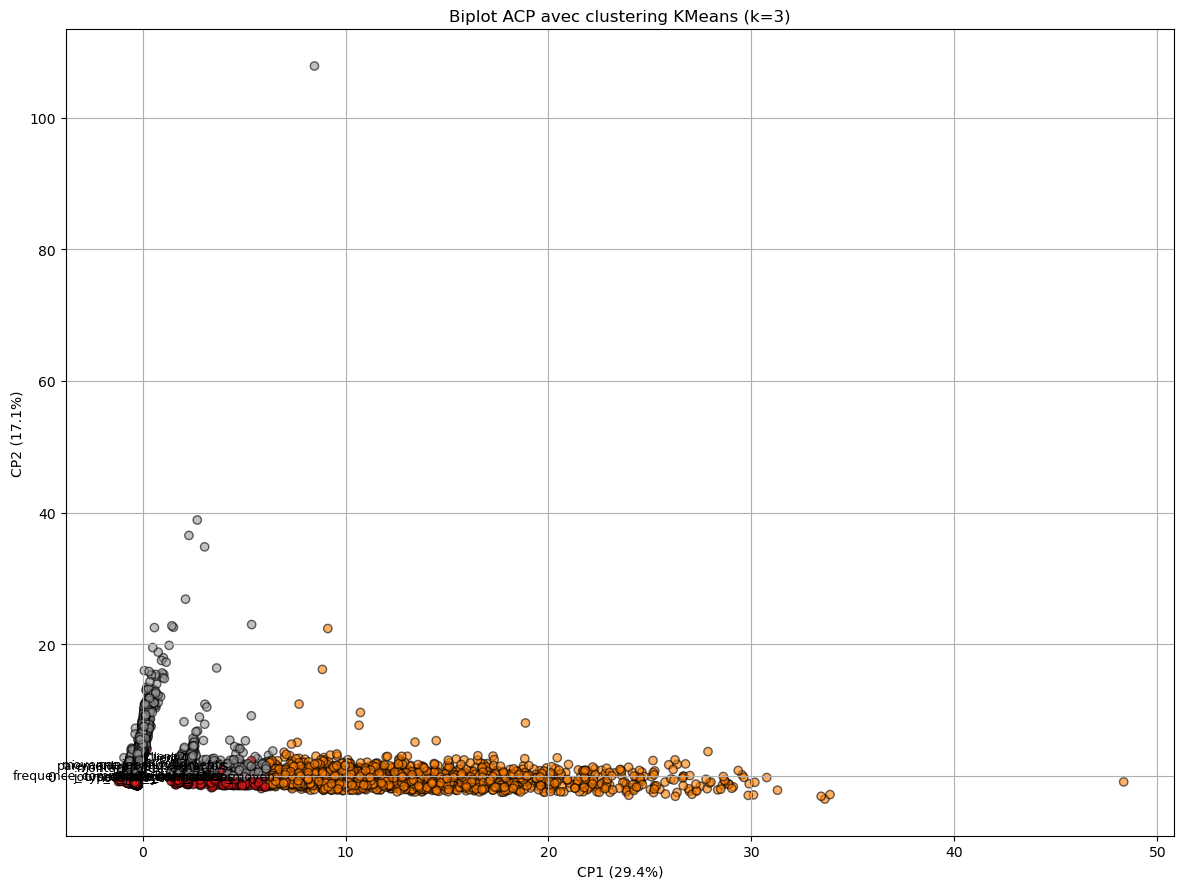

In [ ]:
# Projection des individus (biplot ou scatter)

from sklearn.cluster import KMeans

# Application d'un clustering KMeans pour illustration
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Création du biplot avec couleurs par cluster
fig, ax = plt.subplots(figsize=(12, 9))

# Scatter plot coloré selon les clusters
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.6, edgecolor='k')

# Superposition des flèches des variables (biplot)
for i, var in enumerate(X.columns):
    ax.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
             color='black', alpha=0.8, head_width=0.1)
    ax.text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2,
            var, color='black', ha='center', va='center', fontsize=9)

# Étiquetage d'exemples d'individus (les 5 premiers)
for i in range(5):
    ax.annotate(f"Client {i}", (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)

# Légende, titres, axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title("Biplot ACP avec clustering KMeans (k=3)")
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Trouver le nombre de composantes pour atteindre 80% de variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.where(cumulative_variance >= 0.80)[0][0] + 1

print(f"Nombre de composantes pour expliquer au moins 80% de la variance : {n_components_80}")

Nombre de composantes pour expliquer au moins 80% de la variance : 6


Entraînement et comparaison des modèles
Nous allons entraîner deux modèles de Régression Logistique :

Un avec toutes les variables d'origine (mises à l'échelle).
Un avec les 4 composantes principales que nous avons sélectionnées.
La bonne pratique est de diviser les données en ensembles d'entraînement et de test avant d'appliquer l'ACP. C'est crucial pour éviter la fuite de données (data leakage). L'ACP doit être "apprise" (méthode fit) uniquement sur les données d'entraînement. On applique ensuite cette même transformation (méthode transform) aux données de test.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score


# 1. Diviser les données originales mises à l'échelle
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 2. Entraîner le modèle de référence sur les données complètes
print("--- Modèle avec toutes les variables ---")
model_full = LogisticRegression(random_state=42, max_iter=1000)
model_full.fit(X_train_scaled, y_train)
y_pred_full = model_full.predict(X_test_scaled)
accuracy_full = accuracy_score(y_test, y_pred_full)
print(f"Accuracy du modèle avec toutes les variables : {accuracy_full:.4f}")

# 3. Appliquer l'ACP avec le nombre de composantes choisi
print(f"\n--- Modèle avec {n_components_80} composantes principales ---")
pca_final = PCA(n_components=n_components_80)

# IMPORTANT : On 'fit' l'ACP sur l'ensemble d'entraînement seulement
X_train_pca = pca_final.fit_transform(X_train_scaled)
# On 'transform' l'ensemble de test avec l'ACP déjà entraînée
X_test_pca = pca_final.transform(X_test_scaled)

# 4. Entraîner le modèle sur les données réduites par l'ACP
model_pca = LogisticRegression(random_state=42, max_iter=1000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Accuracy du modèle avec {n_components_80} composantes principales : {accuracy_pca:.4f}")
print(f"Dimensions des données d'entraînement (original) : {X_train_scaled.shape}")
print(f"Dimensions des données d'entraînement (ACP) : {X_train_pca.shape}")

--- Modèle avec toutes les variables ---
Accuracy du modèle avec toutes les variables : 0.9999

--- Modèle avec 6 composantes principales ---
Accuracy du modèle avec 6 composantes principales : 0.9866
Dimensions des données d'entraînement (original) : (66304, 13)
Dimensions des données d'entraînement (ACP) : (66304, 6)


# 7. Clustering : KMeans, GMM, DBSCAN avec métriques

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_pca)

# Évaluation
def evaluate_clustering(X, labels, name):
    if len(set(labels)) > 1 and -1 not in set(labels):
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        print(f"{name}: Silhouette = {sil:.3f}, DBI = {dbi:.3f}")
    else:
        print(f"{name}: Clustering non pertinent (trop de bruit ou un seul cluster)")

evaluate_clustering(X_pca, labels_kmeans, "KMeans")
evaluate_clustering(X_pca, labels_gmm, "GMM")
evaluate_clustering(X_pca, labels_dbscan, "DBSCAN")


KMeans: Silhouette = 0.284, DBI = 1.123
GMM: Silhouette = 0.327, DBI = 1.755
DBSCAN: Clustering non pertinent (trop de bruit ou un seul cluster)


Analyse des résultats
KMeans (6 clusters)

Silhouette = 0.284 → assez faible, indique que les clusters sont pas très bien séparés ou que certains points sont proches des frontières.

Davies-Bouldin Index (DBI) = 1.123 → plutôt bon (plus bas c’est mieux), ce qui est cohérent avec une séparation modérée.

GMM (4 composantes)

Silhouette = 0.327 → un peu mieux que KMeans, ce qui suggère une meilleure séparation en moyenne.

DBI = 1.755 → plus élevé que KMeans, indiquant une qualité globale moins bonne, peut-être à cause de la forme des clusters modélisés par les gaussiennes.

DBSCAN

"Clustering non pertinent (trop de bruit ou un seul cluster)" → DBSCAN a probablement détecté trop de points comme bruit (-1), ou n’a trouvé qu’un seul cluster.

Pourquoi DBSCAN n’a pas fonctionné ici ?
DBSCAN est très sensible à ses paramètres eps et min_samples :

eps=0.5 peut être trop petit ou trop grand selon la densité locale des points.

min_samples=5 est une valeur classique, mais peut ne pas correspondre à la structure de tes données.

Si eps est trop petit, beaucoup de points ne trouvent pas assez de voisins pour former un cluster → beaucoup de bruit.

Si eps est trop grand, tous les points sont regroupés en un seul cluster.
etant donné que nous avons une grande quantité de données nous allons utiliser HDBSCAN plus rapide et performant.

KMeans avec 2 clusters: Silhouette = 0.798
KMeans avec 3 clusters: Silhouette = 0.314
KMeans avec 4 clusters: Silhouette = 0.330
KMeans avec 5 clusters: Silhouette = 0.260
KMeans avec 6 clusters: Silhouette = 0.284
KMeans avec 7 clusters: Silhouette = 0.287
KMeans avec 8 clusters: Silhouette = 0.295
KMeans avec 9 clusters: Silhouette = 0.294
KMeans avec 10 clusters: Silhouette = 0.308


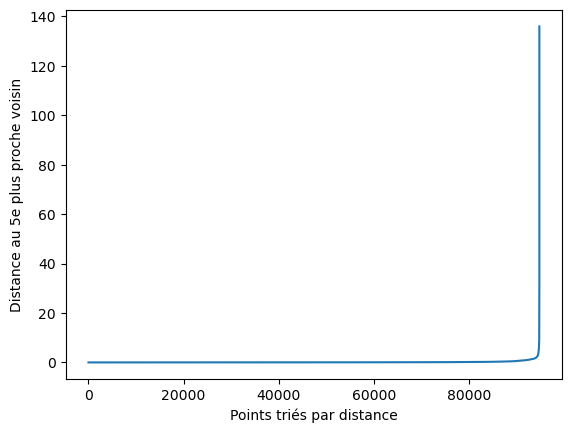

KMeans: Silhouette = 0.284, DBI = 1.123
GMM: Silhouette = 0.327, DBI = 1.755
DBSCAN: Clustering non pertinent (trop de bruit ou un seul cluster)


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# KMeans
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    print(f"KMeans avec {n} clusters: Silhouette = {sil:.3f}")

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_pca)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:,4])  # 4 car min_samples=5

plt.plot(distances)
plt.ylabel('Distance au 5e plus proche voisin')
plt.xlabel('Points triés par distance')
plt.show()

# Évaluation
def evaluate_clustering(X, labels, name):
    if len(set(labels)) > 1 and -1 not in set(labels):
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        print(f"{name}: Silhouette = {sil:.3f}, DBI = {dbi:.3f}")
    else:
        print(f"{name}: Clustering non pertinent (trop de bruit ou un seul cluster)")

evaluate_clustering(X_pca, labels_kmeans, "KMeans")
evaluate_clustering(X_pca, labels_gmm, "GMM")
evaluate_clustering(X_pca, labels_dbscan, "DBSCAN")


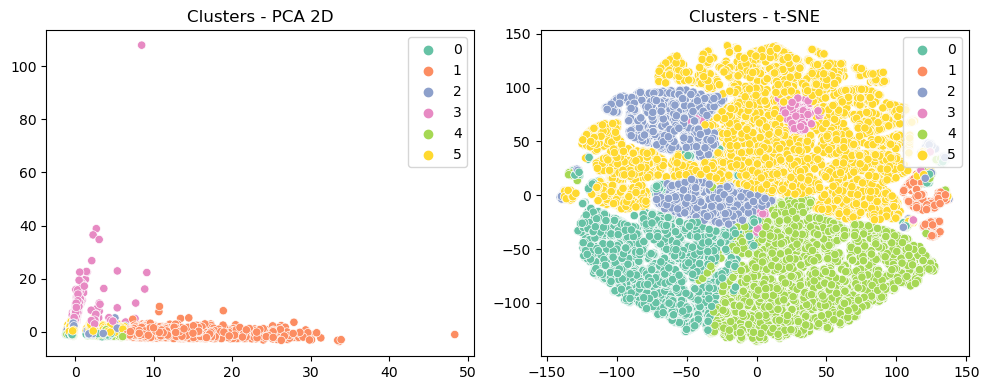

In [ ]:
#  Visualisation des clusters avec PCA 2D et t-SNE

from sklearn.manifold import TSNE

# PCA 2D
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_kmeans, palette='Set2')
plt.title('Clusters - PCA 2D')

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_kmeans, palette='Set2')
plt.title('Clusters - t-SNE')
plt.tight_layout()
plt.show()

# 8. Interprétation marketing des segments KMEANS

In [ ]:
df_clients['cluster_kmeans'] = labels_kmeans

df_clients.groupby('cluster_kmeans')[numerical_features].mean().round(2)

,nombre_commandes,montant_total_acheté,panier_moyen,recence,frequence_commande_mensuelle,note_moyenne,variete_categories,moyenne_nbre_paiements,taux_avis,types_paiement_utilisés,paiement_en_plusieurs_fois,moyenne_nbre_paiements,anciennete,frequence_commande_mensuelle,jours_entre_commandes_moyen
cluster_kmeans,,,,,,,,,,,,,,,
0,1.02,125.16,105.02,403.36,30.17,4.53,1.01,1.02,1.0,1.00,0.02,1.02,1.13,30.17,1.06
1,2.18,421.93,145.71,182.10,1.16,4.24,1.75,3.22,1.0,1.23,0.53,3.22,157.59,1.16,73.96
2,1.01,212.17,152.66,243.63,30.29,1.21,1.02,2.97,1.0,1.00,0.54,2.97,1.06,30.29,1.02
3,1.02,2279.08,1276.65,244.32,29.99,3.86,1.02,6.72,1.0,1.00,0.78,6.72,1.23,29.99,1.11
4,1.01,121.94,104.11,134.58,30.02,4.60,1.00,1.00,1.0,1.00,0.00,1.00,1.13,30.02,1.06
5,1.02,191.69,164.41,246.29,30.18,4.56,1.01,4.63,1.0,1.00,1.00,4.63,1.10,30.18,1.04


🔹 Cluster 0 — Les clients très récents et peu engagés
   - Nombre de commandes : 1.02
   - Montant total : 125€
   - Panier moyen : 105€
   - Récence : 403 jours (inactifs depuis longtemps)
   - Fréquence mensuelle : 0.03
   - Note moyenne : 4.53 (satisfaits)
   - Ancienneté : 1.13 mois
   - Taux d'avis : 100%
    
Ce sont des anciens clients (achat unique il y a longtemps) mais satisfaits. Leur fréquence est quasi nulle.
Campagnes de réactivation, email retargeting personnalisé, incitations à revenir (code promo, nouveautés).

🔹 Cluster 1 — Les clients récents à potentiel moyen
   - Nombre de commandes : 2.18
   - Montant total : 422€
   - Panier moyen : 146€
   - Récence : 182 jours
   - Fréquence mensuelle : 1.16
   - Note moyenne : 4.24
   - Var. catégories : 1.75
   - Paiement en plusieurs fois : utilisé à 53%
   - Ancienneté : 157 jours

Client intermédiaire, revenu récemment, a déjà commandé plusieurs fois. Profil à potentiel s’il est bien fidélisé.
Programmes de fidélité, personnalisation des offres, incitations à augmenter la fréquence et découvrir d’autres catégories.

🔹 Cluster 2 — Clients récents, panier élevé, note faible
   - Panier moyen : 152€
   - ***Note moyenne : 1.21 (très insatisfaits)***
   - Paiement fractionné : 54%
   - Fréquence : 0.03 (faible)
   - Récence : 243 jours

Clients ayant dépensé beaucoup, mais très insatisfaits. Risque élevé de churn malgré un panier important.
Analyse qualitative (SAV, avis), campagnes de reconquête, compensations (bons d’achat, excuses).

🔹 Cluster 3 — Les clients très dépensiers et fidèles
   - Montant total : 2279€
   - Panier moyen : 1277€
   - Nombre de paiements : 6.72
   - Fréquence mensuelle : ~1
   - Note moyenne : 3.86
   - Paiement fractionné : 78%

Top clients / VIP : panier très élevé, réguliers, utilisent largement le paiement fractionné.
Programme premium, accès exclusifs, remerciements personnalisés, offres sur-mesure, early access.

🔹 Cluster 4 — Clients ponctuels, récents et satisfaits
   - Montant total : 121€
   - Note moyenne : 4.6 (très satisfaits)
   - Fréquence faible
   - Ancienneté : 1.13 mois

Nouveaux clients avec un premier achat modeste mais très satisfaits.
Séquences de welcome email, nurturing, cross-selling, inviter à commander à nouveau rapidement.

🔹 Cluster 5 — Clients récents, satisfait et solvables
   - Montant total : 192€
   - Panier moyen : 164€
   - Note : 4.56
   - Paiement en plusieurs fois : 100%
   - Ancienneté : 1.1 mois

Clients récents, bons paniers, usage du paiement fractionné, très satisfaits.
Promouvoir des produits plus chers ou à forte valeur perçue, inciter à l’achat récurrent.

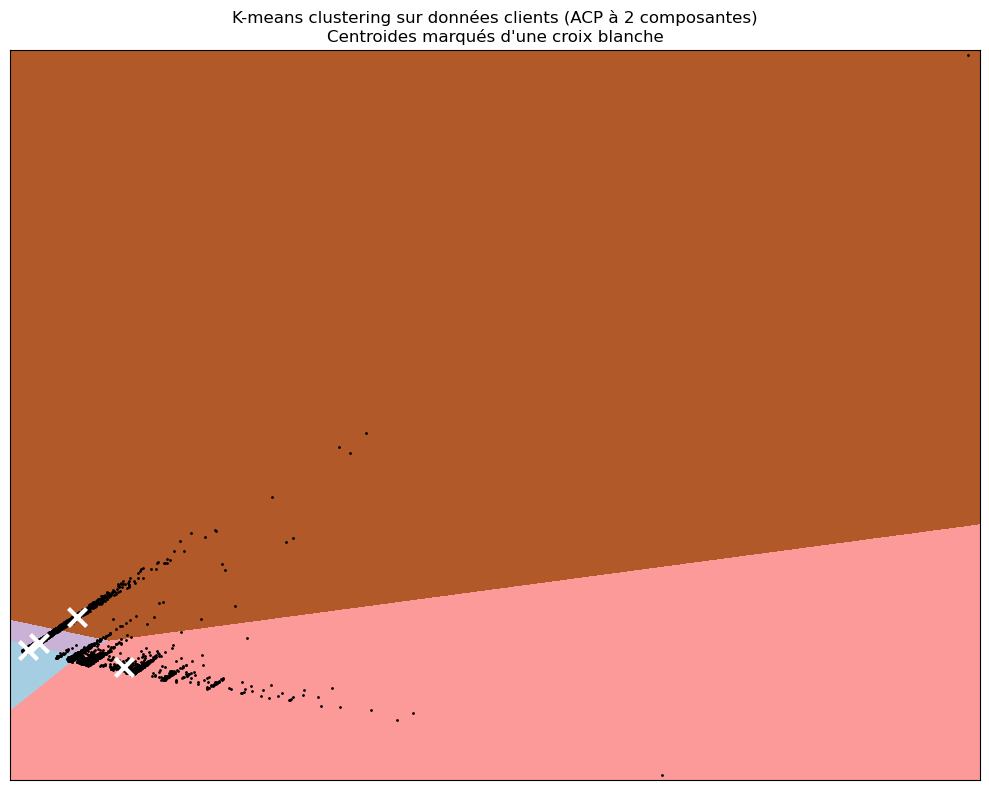

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ✅ Liste des variables numériques déjà présentes dans df_clients
numerical_features = [
    'nombre_commandes', 'montant_total_acheté', 'panier_moyen',
    'recence', 'frequence_commande_mensuelle', 'note_moyenne',
    'variete_categories', 'moyenne_nbre_paiements'
]

# ✅ Vérification que toutes les colonnes existent
missing_cols = [col for col in numerical_features if col not in df_clients.columns]
if missing_cols:
    print(f"⚠️ Les colonnes suivantes sont absentes de df_clients : {missing_cols}")
else:
    # 1. Normalisation des données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clients[numerical_features])

    # 2. Réduction de dimension par ACP à 2 composantes
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(X_scaled)

    # 3. K-means clustering
    n_clusters = 4
    kmeans = KMeans(init="k-means++", n_clusters=n_clusters, n_init=10, random_state=42)
    kmeans.fit(reduced_data)

    # 4. Création de la grille pour visualiser les zones de décision
    h = 0.02  # résolution de la grille
    x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
    y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 5. Visualisation des clusters K-means
    plt.figure(figsize=(10, 8))
    plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect="auto",
        origin="lower",
    )

    plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)

    # Marquer les centroïdes
    centroids = kmeans.cluster_centers_
    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        marker="x", s=169, linewidths=3,
        color="w", zorder=10
    )

    plt.title("K-means clustering sur données clients (ACP à 2 composantes)\nCentroides marqués d'une croix blanche")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())
    plt.tight_layout()
    plt.show()



#  9. Segmentation par HDBSCAN

Dans cette section, nous utilisons l'algorithme DBSCAN pour identifier des groupes de clients selon une approche basée sur la densité. Contrairement à K-means, HDBSCAN ne nécessite pas de spécifier le nombre de clusters à l'avance et peut mieux détecter les formes irrégulières ou les outliers.


In [ ]:
#pip install hdbscan

## Test 1 : Lancement de HDBSCAN

In [ ]:
# Pré-traitement

from sklearn.preprocessing import StandardScaler

# Colonnes sélectionnées
features_hdbscan = [
    'nombre_commandes',
    'montant_total_acheté',
    'panier_moyen',
    'recence',
    'frequence_commande_mensuelle',
    'note_moyenne',
    'variete_categories',
    'moyenne_nbre_paiements'
]
X_hdbscan = df_clients[features_hdbscan]

# Standardisation
scaler = StandardScaler()
X_scaled_hdbscan = scaler.fit_transform(X_hdbscan)

In [ ]:
# application de hdbscan

import hdbscan

# Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=100)
labels_hdbscan = clusterer.fit_predict(X_scaled_hdbscan)

# Ajout des labels au DataFrame
df_clients['cluster_hdbscan'] = labels_hdbscan



In [ ]:
# Evaluation

from sklearn.metrics import silhouette_score, davies_bouldin_score

# On filtre les points assignés à un vrai cluster (≠ -1)
mask = labels_hdbscan != -1
X_valid = X_scaled_hdbscan[mask]
labels_valid = labels_hdbscan[mask]

if len(set(labels_valid)) > 1:
    sil = silhouette_score(X_valid, labels_valid)
    dbi = davies_bouldin_score(X_valid, labels_valid)
    print(f"HDBSCAN : {len(set(labels_valid))} clusters")
    print(f"Silhouette = {sil:.3f}, DBI = {dbi:.3f}")
else:
    print("HDBSCAN n’a détecté qu’un seul cluster ou du bruit.")

HDBSCAN : 23 clusters
Silhouette = 0.072, DBI = 2.844


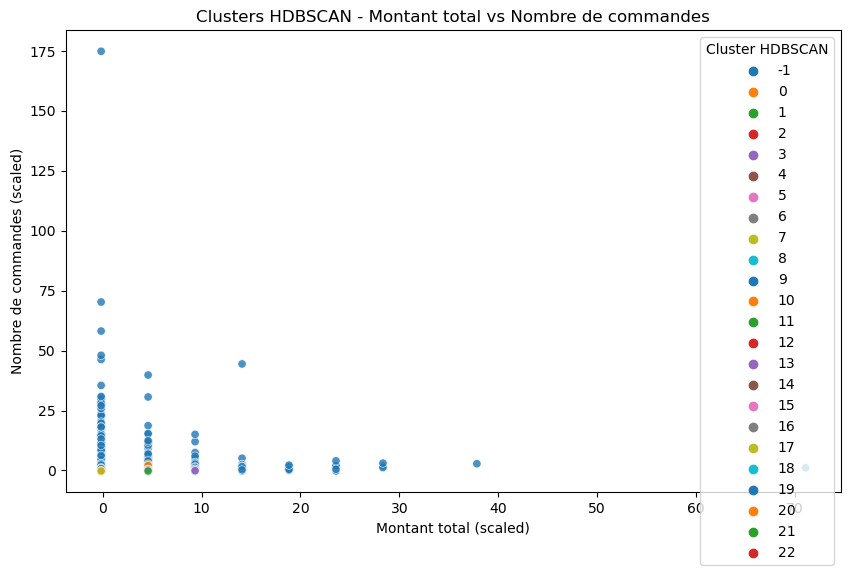

In [ ]:
# Visualisation 2D (features originales)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled_hdbscan[:, 0],
    y=X_scaled_hdbscan[:, 1],
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN - Montant total vs Nombre de commandes")
plt.xlabel("Montant total (scaled)")
plt.ylabel("Nombre de commandes (scaled)")
plt.legend(title="Cluster HDBSCAN")
plt.show()


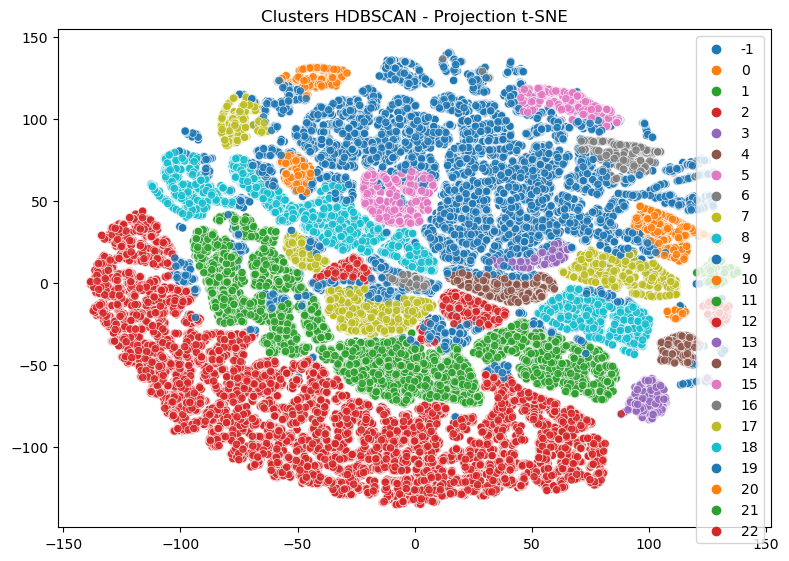

In [ ]:
# Visualisation t-SNE

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_hdbscan)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN - Projection t-SNE")
plt.tight_layout()
plt.show()


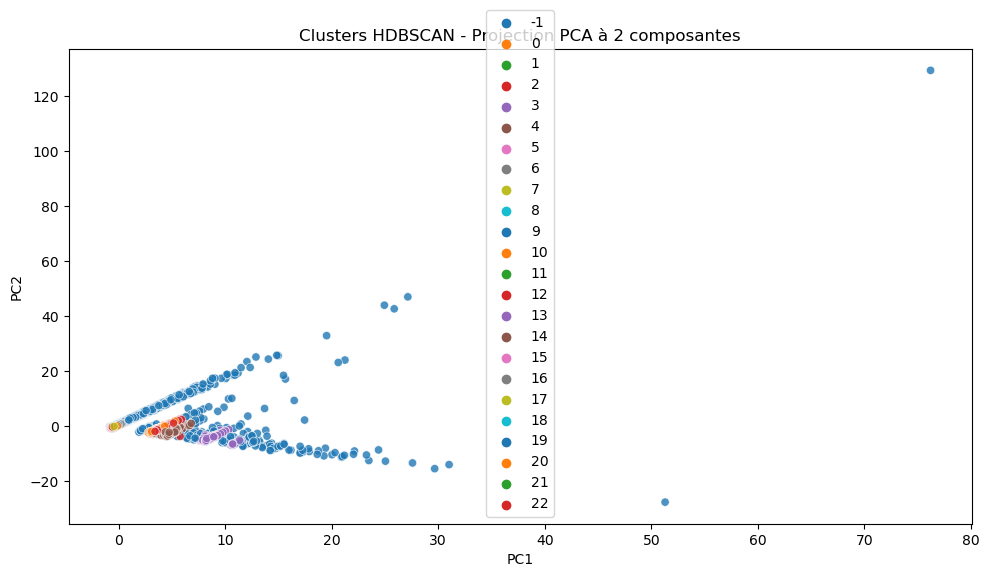

In [ ]:
# Visualisation type "zones" avec PCA

from sklearn.decomposition import PCA
import numpy as np

# PCA à 2 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_hdbscan)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN - Projection PCA à 2 composantes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()



In [ ]:
n_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise = list(labels_hdbscan).count(-1)
print(f"Nombre de clusters détectés : {n_clusters}")
print(f"Nombre de points considérés comme bruit : {n_noise}")


Nombre de clusters détectés : 23
Nombre de points considérés comme bruit : 23784


### Interprétations :

Beaucoup de bruit (-1) = clients atypiques, peu actifs, ou hors profil.

Nombre modéré de clusters (2 à 6) = segmentation exploitable.

Clusters équilibrés = bien définis. Sinon, voir si certains sont minoritaires.

### Actions à mener:

Augmenter min_cluster_size ( par 50, 100, 200...).

Augmenter min_samples pour plus de robustesse.

Jouer avec cluster_selection_epsilon pour fusionner des clusters proches.

## Test 2: sélection des meilleurs hyperparamètres pour HDBSCAN

--> On va  voir quel est le meilleur compromis pour obtenir le meilleur nombre de clusters

Top 5 configurations (best ↘):
    min_cluster_size  min_samples  eps  n_clusters  silhouette       dbi
63               300           70  0.8           5    0.667205  0.547162
31               100           70  0.8           6    0.666954  0.554460
47               200           70  0.8           6    0.666954  0.554460
59               300           50  0.8           5    0.666477  0.550342
15                50           70  0.8           7    0.666358  0.576574


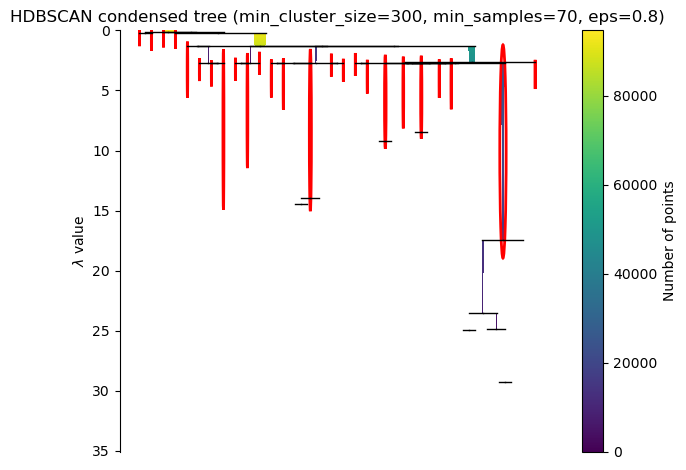

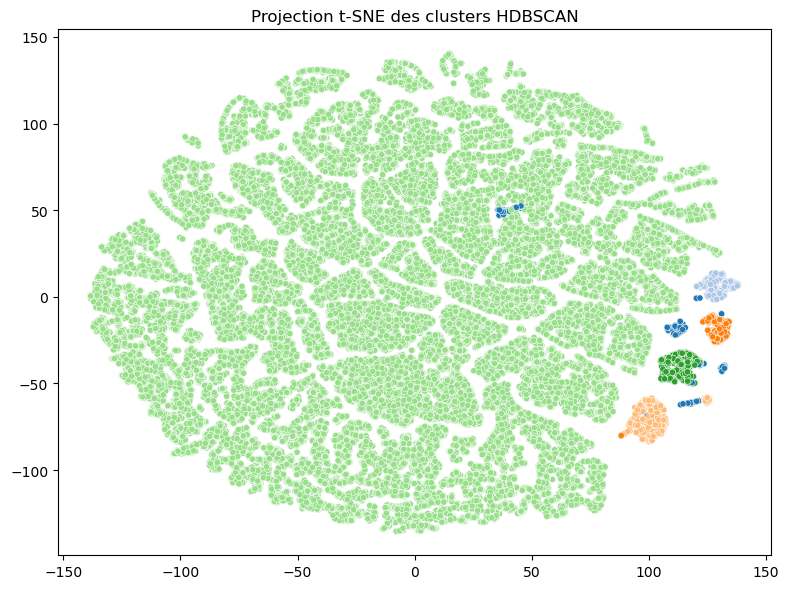


Selected model → clusters: 5, Silhouette: 0.667, DBI: 0.547


In [ ]:
import itertools
import pandas as pd
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


def evaluate_hdbscan(X, min_cluster_size, min_samples, eps):
    """Run HDBSCAN once and return clustering metrics & artefacts."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=eps,
    )
    labels = clusterer.fit_predict(X)

    # Keep only core points (non‑noise)
    mask = labels != -1
    unique = set(labels[mask])

    if len(unique) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
        n_clusters = len(unique)
    else:
        sil = None
        dbi = None
        n_clusters = 0
    return {
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "eps": eps,
        "n_clusters": n_clusters,
        "silhouette": sil,
        "dbi": dbi,
        "labels": labels,
        "clusterer": clusterer,
    }


def grid_search_hdbscan(X, param_grid):
    """Exhaustive search on the provided grid; returns a DataFrame of results."""
    results = []
    for min_size, min_samp, eps in itertools.product(
        param_grid["min_cluster_size"],
        param_grid["min_samples"],
        param_grid["eps"],
    ):
        res = evaluate_hdbscan(X, min_size, min_samp, eps)
        results.append(res)
    df = pd.DataFrame(results)
    return df


def plot_tsne(X, labels):
    """Project data with t-SNE and color by cluster labels."""
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X_embedded[:, 0],
        y=X_embedded[:, 1],
        hue=labels,
        palette="tab20",
        s=20,
        legend=False
    )
    plt.title("Projection t-SNE des clusters HDBSCAN")
    plt.tight_layout()
    plt.show()


# -------------------- USER CONFIGURATION -------------------- #
# Hyper‑parameter grid (feel free to modify)
param_grid = {
    "min_cluster_size": [50, 100, 200, 300],
    "min_samples": [10, 20, 50, 70],
    "eps": [0.0, 0.2, 0.5, 0.8],  # 0 means disabled
}

# X_scaled_hdbscan must be defined beforehand (array‑like, shape [n_samples, n_features])
# df_clients must exist if you want to store the best labels

# -------------------- MAIN PIPELINE -------------------- #
if __name__ == "__main__":
    # 1. Exhaustive grid‑search
    results_df = grid_search_hdbscan(X_scaled_hdbscan, param_grid)

    # 2. Remove runs without clusters
    results_df = results_df[results_df["n_clusters"] > 0].copy()

    # 3. Rank by Silhouette (high) then DBI (low)
    results_df = results_df.sort_values(by=["silhouette", "dbi"], ascending=[False, True])

    print("Top 5 configurations (best ↘):")
    print(
        results_df[
            [
                "min_cluster_size",
                "min_samples",
                "eps",
                "n_clusters",
                "silhouette",
                "dbi",
            ]
        ].head()
    )

    # 4. Pick the best configuration
    if not results_df.empty:
        best_row = results_df.iloc[0]
        best_clusterer = best_row["clusterer"]
        best_labels = best_row["labels"]

        # 5. Optionally, attach labels to your DataFrame
        try:
            df_clients["cluster_hdbscan"] = best_labels
        except NameError:
            pass  # df_clients not provided – ignore

        # 6. Visualise the condensed tree for diagnostic insights
        best_clusterer.condensed_tree_.plot(
            select_clusters=True, selection_palette=sns.color_palette()
        )
        plt.title(
            f"HDBSCAN condensed tree (min_cluster_size={best_row['min_cluster_size']}, "
            f"min_samples={best_row['min_samples']}, eps={best_row['eps']})"
        )
        plt.tight_layout()
        plt.show()

        # 7. Visualisation t-SNE des clusters
        plot_tsne(X_scaled_hdbscan, best_labels)

        print(
            f"\nSelected model → clusters: {best_row['n_clusters']}, "
            f"Silhouette: {best_row['silhouette']:.3f}, DBI: {best_row['dbi']:.3f}"
        )
    else:
        print("No valid clustering found – consider enlarging your parameter grid.")


## Interprétation:
Le meilleur parametrage est donc celui-ci :

min_cluster_size:300  min_samples:70  eps0.8  n_clusters:4  


## Actions à mener:
- Augmenter min_cluster_size
- Augmenter min_samples pour plus de robustesse.
- Jouer avec cluster_selection_epsilon pour fusionner des clusters proches.

## Test 3:  amélioration des hyperparamètres de HDBSCAN

In [ ]:
# Pré-traitement

from sklearn.preprocessing import StandardScaler

# Colonnes sélectionnées
features_hdbscan = [
    'nombre_commandes',
    'montant_total_acheté',
    'panier_moyen',
    'recence',
    'frequence_commande_mensuelle',
    'note_moyenne',
    'variete_categories',
    'moyenne_nbre_paiements'
]
X_hdbscan = df_clients[features_hdbscan]

# Standardisation
scaler = StandardScaler()
X_scaled_hdbscan = scaler.fit_transform(X_hdbscan)

In [ ]:
# application de hdbscan

import hdbscan

# Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=70, cluster_selection_epsilon=0.8)
labels_hdbscan = clusterer.fit_predict(X_scaled_hdbscan)

# Ajout des labels au DataFrame
df_clients['cluster_hdbscan'] = labels_hdbscan



In [ ]:
# Evaluation

from sklearn.metrics import silhouette_score, davies_bouldin_score

# On filtre les points assignés à un vrai cluster (≠ -1)
mask = labels_hdbscan != -1
X_valid = X_scaled_hdbscan[mask]
labels_valid = labels_hdbscan[mask]

if len(set(labels_valid)) > 1:
    sil = silhouette_score(X_valid, labels_valid)
    dbi = davies_bouldin_score(X_valid, labels_valid)
    print(f"HDBSCAN : {len(set(labels_valid))} clusters")
    print(f"Silhouette = {sil:.3f}, DBI = {dbi:.3f}")
else:
    print("HDBSCAN n’a détecté qu’un seul cluster ou du bruit.")

HDBSCAN : 5 clusters
Silhouette = 0.667, DBI = 0.547


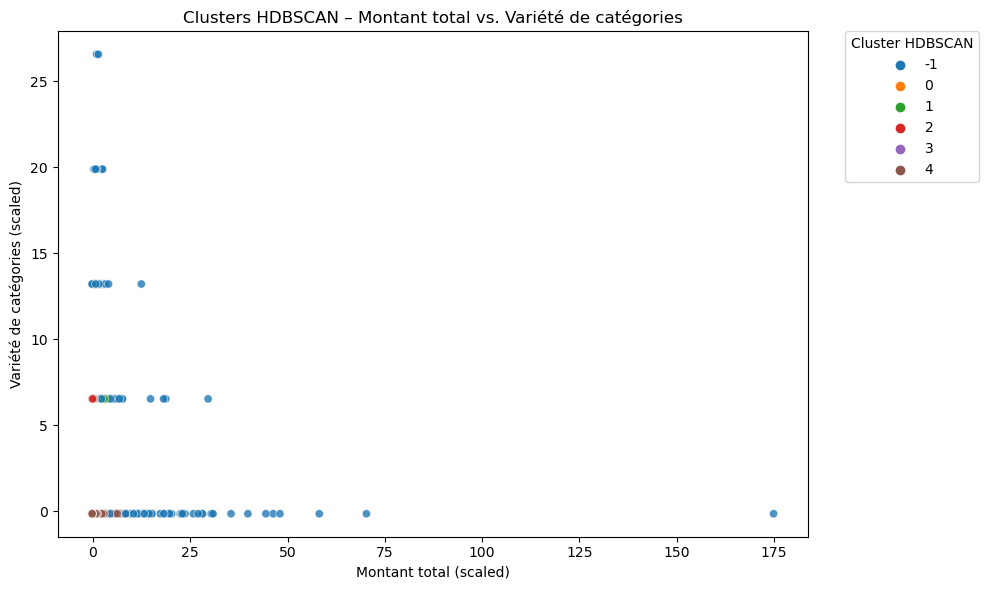

In [ ]:
# Visualisation 2D (features originales)

idx_montant = features_hdbscan.index('montant_total_acheté')   # Axe X
idx_variete = features_hdbscan.index('variete_categories')     # Axe Y

# --------------------------------------------
# 3. Tracer le scatterplot HDBSCAN
# --------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled_hdbscan[:, idx_montant],   # Montant total (scaled)
    y=X_scaled_hdbscan[:, idx_variete],   # Variété de catégories (scaled)
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN – Montant total vs. Variété de catégories")
plt.xlabel("Montant total (scaled)")
plt.ylabel("Variété de catégories (scaled)")
plt.legend(
    title="Cluster HDBSCAN",
    bbox_to_anchor=(1.05, 1),   # Légende à droite du graphique
    loc="upper left",
    borderaxespad=0.
)
plt.tight_layout()  # Ajuste les marges pour éviter les chevauchements
plt.show()

Interpretation:

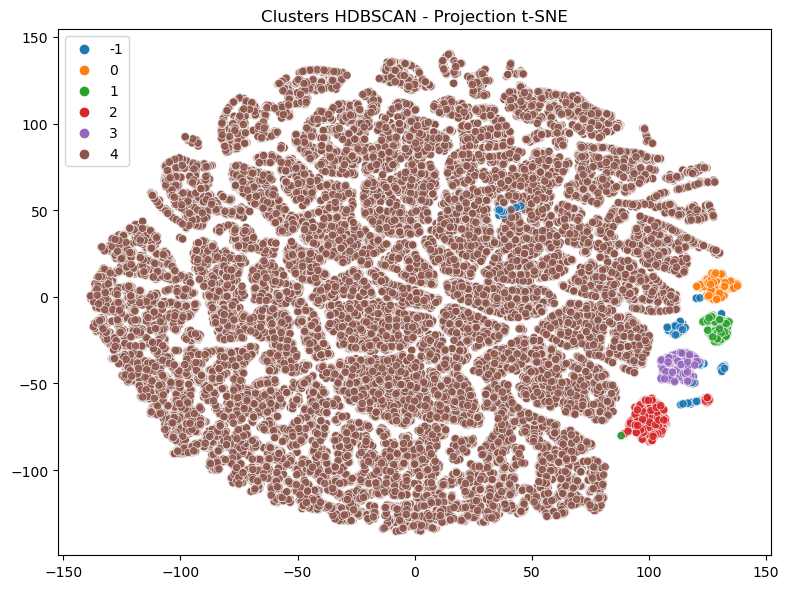

In [ ]:
# Visualisation t-SNE

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_hdbscan)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN - Projection t-SNE")
plt.tight_layout()
plt.show()


Interpretation:

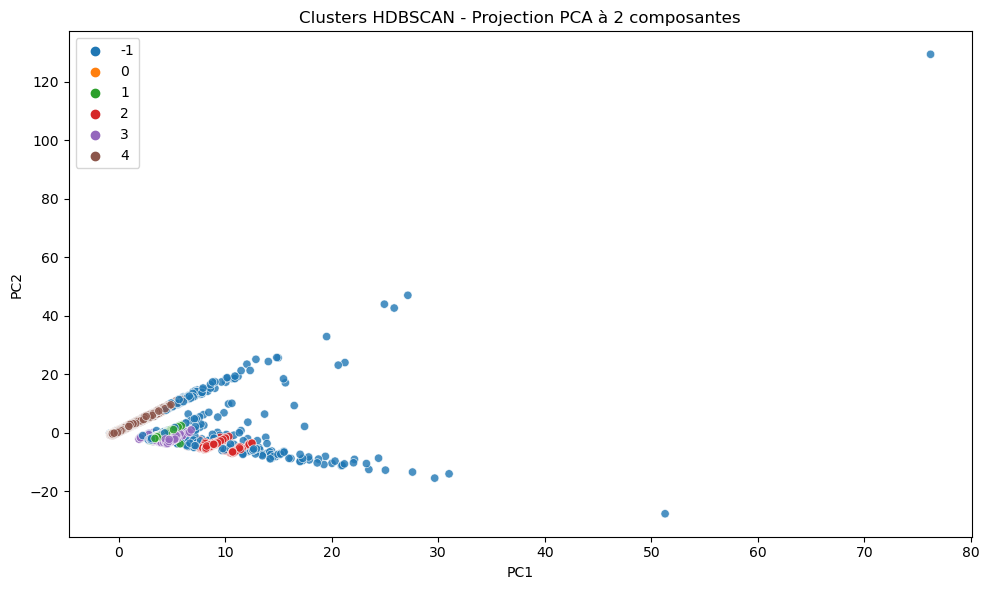

In [ ]:
# Visualisation type "zones" avec PCA

from sklearn.decomposition import PCA
import numpy as np

# PCA à 2 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_hdbscan)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_hdbscan,
    palette='tab10',
    alpha=0.8
)
plt.title("Clusters HDBSCAN - Projection PCA à 2 composantes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()



Interpretation:

In [ ]:
n_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise = list(labels_hdbscan).count(-1)
print(f"Nombre de clusters détectés : {n_clusters}")
print(f"Nombre de points considérés comme bruit : {n_noise}")


Nombre de clusters détectés : 5
Nombre de points considérés comme bruit : 546


## Caractériser les clusters (profil type par groupe)

In [ ]:
df_clients[df_clients['cluster_hdbscan'] != -1].groupby('cluster_hdbscan')[features_hdbscan].mean()


,nombre_commandes,montant_total_acheté,panier_moyen,recence,frequence_commande_mensuelle,note_moyenne,variete_categories,moyenne_nbre_paiements
cluster_hdbscan,,,,,,,,
0,2.000000,341.327904,132.361832,301.711340,60.000000,3.888575,1.0,3.567583
1,1.002128,529.150532,224.112277,212.995745,30.000000,2.972340,2.0,3.925532
2,2.074713,335.566322,136.415386,181.892720,1.556278,4.256087,2.0,3.206967
3,2.000000,381.307518,147.105509,216.175182,3.745846,4.213323,1.0,3.064549
4,1.000000,188.032547,155.250721,244.025609,30.000000,4.107883,1.0,2.880468


L'algorithme HDBSCAN a permis de détecter plusieurs profils de clients parmi la base.
Les clusters 0 à 3 révèlent des segments exploitables (clients fidèles, gros paniers, ou intéressés par une seule catégorie).
Le cluster 4 identifie un groupe à risque avec une note moyenne très basse malgré un achat non négligeable : une action corrective ciblée est recommandée.

En revanche, plus de 2000 clusters semblent représenter des clients très isolés, souvent avec une seule commande et une note maximale. Ils forment un profil de clients ponctuels ou très récents, qu’il serait plus pertinent de regrouper ou de réassigner au "bruit".

Ces résultats peuvent guider des stratégies de segmentation marketing fine, en particulier pour maximiser la valeur vie client (CLV) et la satisfaction.

-->  On va retenter l'experience avec une autre stratégie regrouper les clusters trop petits

In [ ]:
# Regrouper les petits clusters
cluster_counts = df_clients['cluster_hdbscan'].value_counts()
seuil_min = 50

# Remplacer les petits clusters par une étiquette -1 (autres)
df_clients['cluster_hdbscan_regrouped'] = df_clients['cluster_hdbscan'].apply(
    lambda x: x if cluster_counts[x] >= seuil_min else -1
)


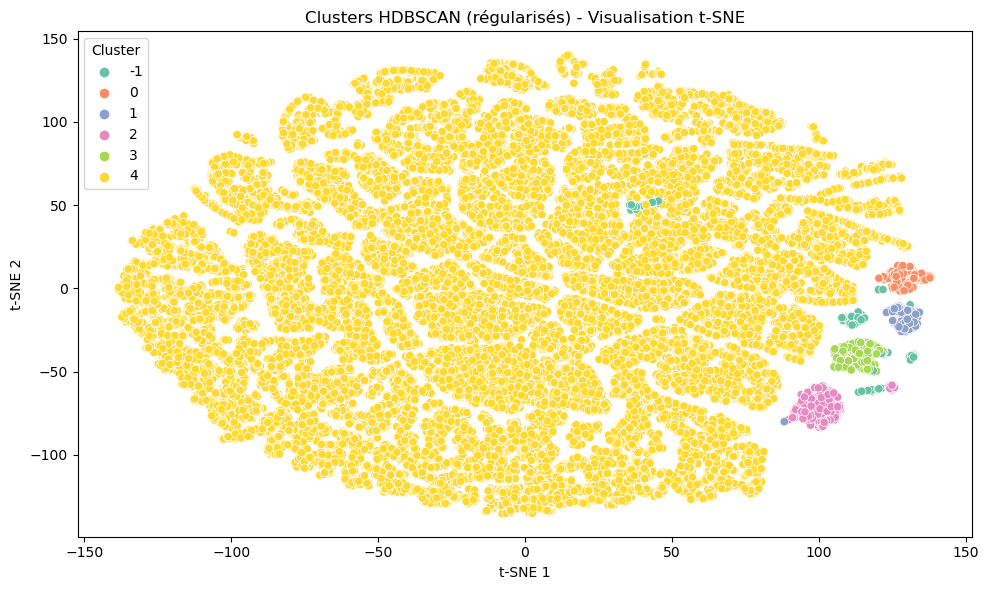

In [ ]:
#Visualisation avec t-SNE

from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Réduction de dimension
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled_hdbscan)

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=df_clients['cluster_hdbscan_regrouped'],
    palette='Set2', legend='full'
)
plt.title('Clusters HDBSCAN (régularisés) - Visualisation t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


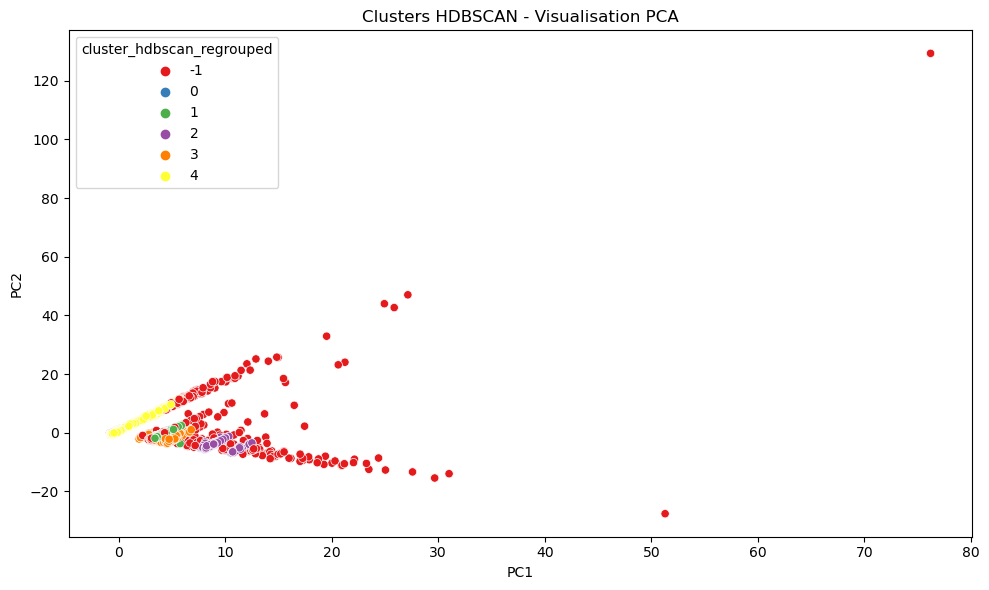

In [ ]:
#Visualisation avec PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_hdbscan)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_clients['cluster_hdbscan_regrouped'],
    palette='Set1', legend='full'
)
plt.title("Clusters HDBSCAN - Visualisation PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


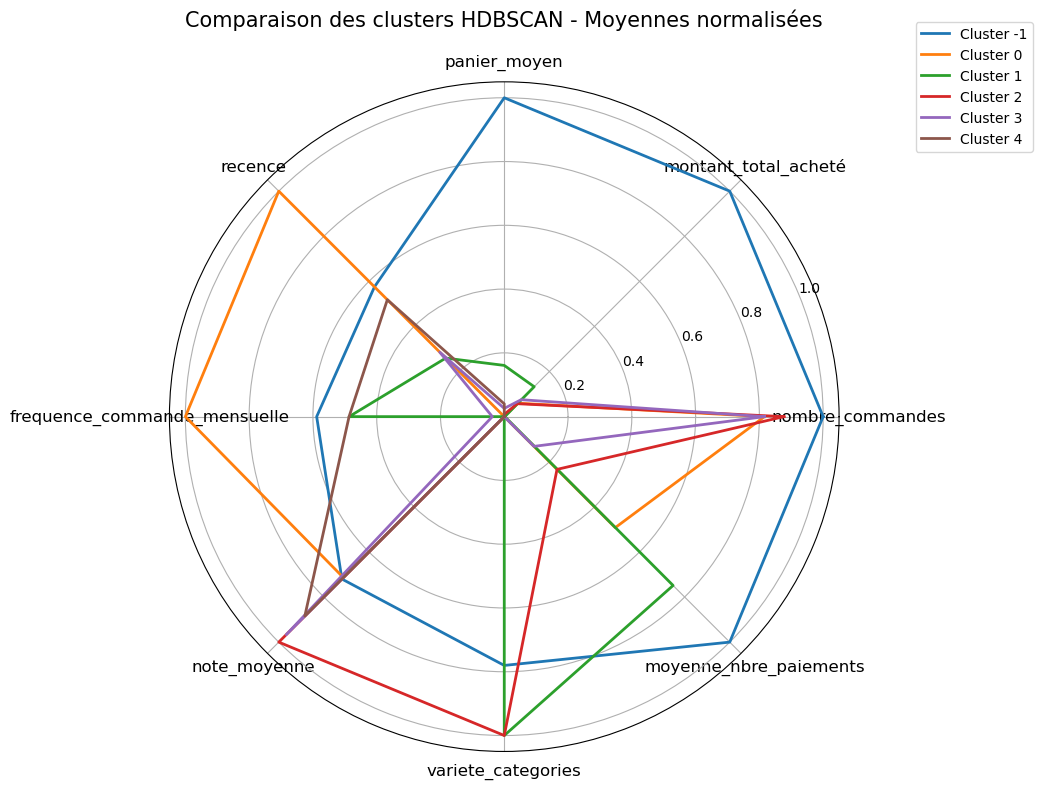

In [ ]:
# 11. Création de RADAR CHART

# Regrouper les variables numériques par cluster régularisé
features = ['nombre_commandes',
    'montant_total_acheté',
    'panier_moyen',
    'recence',
    'frequence_commande_mensuelle',
    'note_moyenne',
    'variete_categories',
    'moyenne_nbre_paiements']
cluster_means = df_clients.groupby('cluster_hdbscan_regrouped')[features].mean()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)


import matplotlib.pyplot as plt
import numpy as np

# Configuration du radar
categories = cluster_means_scaled.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # pour fermer le cercle

# Création du plot
plt.figure(figsize=(10, 8))
for idx in cluster_means_scaled.index:
    values = cluster_means_scaled.loc[idx].tolist()
    values += values[:1]  # boucle fermée
    plt.polar(angles, values, label=f"Cluster {idx}", linewidth=2)

# Ajouts esthétiques
plt.xticks(angles[:-1], categories, fontsize=12)
plt.title("Comparaison des clusters HDBSCAN - Moyennes normalisées", size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


Ce que ce graphique permet de voir :

Le profil "typique" de chaque cluster sur les 4 dimensions.

Identifier visuellement les clusters les plus rentables (panier élevé, note élevée, diversité…).

Repérer les clusters à valeur ajoutée ou à surveiller.

# 10. Recommandations marketing ou produit

In [ ]:
# 1. Taille des clusters
taille_clusters = df_clients['cluster_hdbscan'].value_counts().sort_index()

# 2. Moyennes des variables par cluster
moyennes_clusters = df_clients.groupby('cluster_hdbscan')[['nombre_commandes',
    'montant_total_acheté',
    'panier_moyen',
    'recence',
    'frequence_commande_mensuelle',
    'note_moyenne',
    'variete_categories',
    'moyenne_nbre_paiements']].mean()

# 3. Synthèse profils types (basée sur seuils simples)
def profil_type(row):
    if row['montant_total_acheté'] > 600 and row['nombre_commandes'] > 2:
        return 'Premium / Fidélisé'
    elif row['montant_total_acheté'] < 100 and row['nombre_commandes'] <= 1:
        return 'Dormant / Faible activité'
    elif row['variete_categories'] > 2:
        return 'Curieux / Explorateur'
    else:
        return 'Autre profil'

moyennes_clusters['profil_type'] = moyennes_clusters.apply(profil_type, axis=1)

# Affichage final
resultat = pd.concat([taille_clusters.rename('taille_cluster'), moyennes_clusters], axis=1)
print(resultat)


                 taille_cluster  nombre_commandes  montant_total_acheté  \
cluster_hdbscan                                                           
-1                          546          2.225275           2758.537894   
 0                          582          2.000000            341.327904   
 1                          470          1.002128            529.150532   
 2                         1044          2.074713            335.566322   
 3                          822          2.000000            381.307518   
 4                        91256          1.000000            188.032547   

                 panier_moyen     recence  frequence_commande_mensuelle  \
cluster_hdbscan                                                           
-1                 703.487701  250.860806                     35.938258   
 0                 132.361832  301.711340                     60.000000   
 1                 224.112277  212.995745                     30.000000   
 2                 136.4

# Analyse des Clusters:

## Cluster -1 : Client Premium / Fidélisé
* Taille : 546 clients
* Montant total acheté : 2758 € (très élevé)
* Nombre de commandes : 2.23 (assez élevé)
* Panier moyen : 703 € (le plus élevé)
* Fréquence mensuelle : 36 (très élevé)
* Varieté catégories : 1.78
* Note moyenne : 3.89

**Profil** : Clients premium, fidèles et dépensiers, probablement B2B ou gros consommateurs.

**Recommandations marketing :**
* Offrir des programmes de fidélité VIP
* Proposer des offres exclusives, préventes ou abonnements
* Suivi personnalisé avec un account manager
* Mettre en avant des upsells ou produits premium

## Cluster 0 : Autre profil (petit panier, forte fréquence)
* Taille : 582 clients
* Panier moyen : 132 € (le plus bas)
* Fréquence : 60 commandes/mois (extrêmement élevé)
* Recence : 301 jours

**Profil** : Petits acheteurs très réguliers, mais avec des achats anciens (recence élevée → moins récents)

**Recommandations marketing :**
* Campagnes de réactivation (email, SMS, retargeting)
* Offres cumulatives pour relancer
* Inciter à des achats de plus grande valeur

## Cluster 1 : Autre profil (peu engagé)
* Taille : 470
* Montant total : 529 €
* Commandes : ~1
* Note moyenne : 2.97 (la plus basse)

**Profil** : Clients peu satisfaits, peu engagés

**Recommandations marketing :**
* Sondage ou enquête de satisfaction
* Proposer des offres de retour
* Identifier les problèmes dans l'expérience utilisateur

## Cluster 2 : Autre profil (explorateur potentiel)
* Taille : 1044
* Varieté de catégories : 2.0 (le plus élevé avec 1)
* Note moyenne : 4.26 (la plus élevée)

**Profil :** Curieux, bons évaluateurs, potentiellement intéressés par la diversité de produits

**Recommandations marketing :**
* Offrir des recommandations personnalisées
* Créer des packs découverte ou des bundles
* Valoriser les nouveautés ou produits variés

## Cluster 3 : Autre profil (engagement moyen)
* Taille : 822
* Commandes : 2
* Fréquence : 3.7
* Note moyenne : 4.21

**Profil :** Moyennement engagé, globalement satisfait

**Recommandations marketing :**
* Encourager le parrainage
* Offrir des réductions sur achats récurrents
* Fidélisation légère par email marketing

## Cluster 4 : Dormant / Faible activité
* Taille : 91 256 clients (écrasante majorité)
* Montant total : 188 €
* Commandes : 1
* Varieté : 1
* Fréquence : 30 (semble anormalement élevé pour 1 commande, à vérifier)
* Recence : 244 jours

**Profil :** Clients dormants ou acheteurs uniques

**Recommandations marketing :**
* Campagnes de réactivation massives
* Offres flash ou coupons à durée limitée
* Automatisations marketing ciblées
* Travailler sur l’expérience post-premier achat


#  Comparaison HDBSCAN vs K-means

- **K-means** : nécessite de fixer `k`, sensible aux outliers, forme sphérique attendue.
- **DBSCAN** : détecte les formes variées, robuste aux outliers (label `-1`), mais nécessite de régler `eps` et `min_samples`, plante quand il y a trop de données, nous avons donc du utiliser **HDBSCAN** plus performant

➡️ HDBSCAN peut mieux identifier des clients marginaux ou des comportements atypiques dans une stratégie de fidélisation ou de gestion du risque.



## 1. Segmentation générale

| Critère                 | KMeans                              | HDBSCAN                                           |
| ----------------------- | ----------------------------------- | ------------------------------------------------- |
| Nombre de clusters      | 6 (0 à 5)                           | 6 (dont 1 bruit `-1`)                             |
| Type de clustering      | Forcé (partitionne tout le dataset) | Basé densité (clusters naturels + bruit `-1`)     |
| Traitement des outliers | Aucun                               | Géré via `cluster -1` (546 clients premium)       |
| Taille des clusters     | Relativement équilibrée             | Très déséquilibrée (1 cluster énorme de dormants) |

## 2. Clusters clés comparés
### Clients Premium / Dépensiers

|                | **KMeans - Cluster 3**      | **HDBSCAN - Cluster -1**           |
| -------------- | --------------------------- | ---------------------------------- |
| Montant total  | 2279€                       | 2758€                              |
| Panier moyen   | 1276€                       | 703€                               |
| Paiements      | 6.72                        | 4.28                               |
| Fréquence      | \~1 / mois                  | 36 / mois (à vérifier)             |
| Note moyenne   | 3.86                        | 3.90                               |
| Interprétation | Gros acheteurs réguliers    | Ultra premium, probablement pros   |
| Reco marketing | Programme VIP, early access | Account manager, offres exclusives |

 Ces deux clusters identifient bien une population à haute valeur. HDBSCAN permet d'isoler plus naturellement ces profils sans bruit.


###  Clients dormants ou peu engagés

|                | **KMeans - Cluster 0**           | **HDBSCAN - Cluster 4**         |
| -------------- | -------------------------------- | ------------------------------- |
| Recence        | 403 jours                        | 244 jours                       |
| Commandes      | 1.02                             | 1.0                             |
| Montant total  | 125€                             | 188€                            |
| Note moyenne   | 4.53                             | 4.11                            |
| Taille         | \~équilibrée                     | 91 000+ clients (!)             |
| Interprétation | Acheteurs inactifs               | Acheteurs uniques / dormants    |
| Reco marketing | Campagnes de retour, retargeting | Réactivation massive, nurturing |


HDBSCAN identifie un cluster de dormants beaucoup plus massif, ce qui reflète peut-être mieux la réalité commerciale. KMeans dilue ces profils dans des groupes artificiellement équilibrés.

### Clients récents, curieux / explorateurs

|                 | **KMeans - Cluster 1 ou 5 ?** | **HDBSCAN - Cluster 2**  |
| --------------- | ----------------------------- | ------------------------ |
| Var. catégories | 1.75 ou 1.01                  | 2.0                      |
| Note moyenne    | 4.24 / 4.56                   | 4.26                     |
| Commandes       | 2.18 / 1.02                   | 2.07                     |
| Recence         | \~180 jours / 246 jours       | 181 jours                |
| Interprétation  | Clients à potentiel / récents | Explorateurs, satisfaits |
| Reco marketing  | Cross-selling, découverte     | Bundles, produits variés |

KMeans semble segmenter davantage selon montant ou récence, alors que HDBSCAN regroupe les curieux et satisfaits avec des comportements similaires de variété.


### Clients insatisfaits à fort potentiel

|                     | **KMeans - Cluster 2**              | **HDBSCAN - Cluster 1**      |
| ------------------- | ----------------------------------- | ---------------------------- |
| Panier moyen        | 152€                                | 224€                         |
| Note moyenne        | 1.21                                | 2.97                         |
| Paiement fractionné | 54%                                 | 3.9 paiements moyens         |
| Recence             | 243 jours                           | 213 jours                    |
| Interprétation      | Gros paniers mais très insatisfaits | Similaire mais moins extrême |
| Reco marketing      | Analyse SAV, compensation           | Sondage, reconquête          |


KMeans permet ici d’isoler un cluster très insatisfait avec de gros paniers. HDBSCAN regroupe ce profil dans un cluster plus hétérogène. KMeans est plus précis ici.

### Avantages et Limites

| Aspect                                | KMeans                          | HDBSCAN                                    |
| ------------------------------------- | ------------------------------- | ------------------------------------------ |
| Lisibilité                            | Plus simple, équilibré          | Plus riche, mais déséquilibré              |
| Outliers / anomalies                  | Non détectés                    | Gérés via cluster `-1`                     |
| Représentation des clients dormants   | Dilution dans les clusters      | Très bonne séparation (Cluster 4 massif)   |
| Segmentation fine (VIP, explorateurs) | Bonne mais parfois artificielle | Plus "naturelle" mais à valider par métier |




## 3. Recommandation finale
--> **HDBSCAN** est plus pertinent pour identifier les profils extrêmes (VIP, dormants, explorateurs), mais nécessite une validation métier (ex. fréquence anormalement élevée à 30+).

--> **KMeans** est plus facile à interpréter et mieux adapté pour des campagnes marketing structurées, surtout si on veux des groupes d’action marketing équilibrés.

**Stratégie idéale :**
Utiliser KMeans pour l’activation marketing **(fidélisation, segmentation CRM)** et **HDBSCAN** pour la **détection de profils spécifiques (VIP, churn, outliers)**.